# Distorted Projector Lens: Seidel Aberrations &amp; Image Distortion

This notebook demonstrates how **Seidel distortion aberrations** affect TEM imaging using Gaussian beam propagation through `DistortedLens` components. We cover:

1. The **canonical Seidel aberration function** $W(x_o, y_o, x_a, y_a)$ and its nine coefficients
2. Three equivalent **parametrizations** (object/aperture position, object/slope, aperture/slope)
3. The **gradient mechanism**: how a phase shift at the lens translates to ray deflection, and why different object points experience different shifts
4. **Single-lens** isotropic (barrel/pincushion) distortion demo
5. **Two-lens** system for spiral (anisotropic) distortion

In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4' 

import jax
from temgym_core.components import Detector
from temgym_core.components import Lens, DistortedLens
from temgym_core.run import run_to_end
from temgym_core.source import square_input_wave
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
%matplotlib widget

jax.config.update("jax_enable_x64", True)


## Seidel Aberration Functions

The **Seidel aberration function** $W$ represents the wavefront error (optical path difference) introduced by a lens. It is a polynomial in four variables: object position $(x_o, y_o)$ and aperture position $(x_a, y_a)$.

### The Canonical Form: $W(x_o, y_o, x_a, y_a)$

$$W(x_o, y_o, x_a, y_a) = \underbrace{A \cdot R^2}_{\text{Pure Phase Shift}} + \underbrace{B \cdot \rho^2}_{\text{Spherical Aberration}} + \underbrace{C \cdot \chi^2}_{\text{Iso. Astigmatism}} + \underbrace{D \cdot R\rho}_{\text{Field Curvature}} + \underbrace{E \cdot R\chi}_{\text{Iso. Distortion}} + \underbrace{F \cdot \rho\chi}_{\text{Iso. Coma}} + \underbrace{e \cdot R\sigma}_{\text{Aniso. Coma}} + \underbrace{f \cdot \rho\sigma}_{\text{Aniso. Astigmatism}} + \underbrace{c \cdot \chi\sigma}_{\text{Aniso. Distortion}}$$

where the **four fundamental quadratic scalars** are:

| Symbol | Expression | Geometric Meaning |
|--------|-----------|-------------------|
| $R$ | $x_o^2 + y_o^2$ | Object position squared (distance from axis at object plane) |
| $\rho$ | $x_a^2 + y_a^2$ | Aperture position squared (distance from axis at lens plane) |
| $\chi$ | $x_o x_a + y_o y_a$ | Dot product: alignment of object & aperture vectors |
| $\sigma$ | $x_o y_a - y_o x_a$ | Cross product: "skewness" of object & aperture vectors |

### Seidel Coefficient Table

| Coeff | Name | Term | Symmetry |
|-------|------|------|----------|
| $A$ | Pure Phase Shift | $A \cdot R^2$ | Isotropic, depends only on object position |
| $B$ | Spherical Aberration | $B \cdot \rho^2$ | Isotropic, depends only on aperture position |
| $C$ | Isotropic Astigmatism | $C \cdot \chi^2$ | Isotropic |
| $D$ | Field Curvature | $D \cdot R\rho$ | Isotropic |
| **$E$** | **Isotropic Distortion** | **$E \cdot R\chi$** | **Isotropic — barrel/pincushion** |
| $F$ | Isotropic Coma | $F \cdot \rho\chi$ | Isotropic |
| $e$ | Anisotropic Coma | $e \cdot R\sigma$ | Anisotropic |
| $f$ | Anisotropic Astigmatism | $f \cdot \rho\sigma$ | Anisotropic |
| **$c$** | **Anisotropic Distortion** | **$c \cdot \chi\sigma$** | **Anisotropic — spiral** |

The code below defines three alternative parametrizations of $W$ and verifies they are algebraically equivalent.

In [2]:
# symbols
z1 = sp.symbols('z1')
xo, yo, xa, ya = sp.symbols('x_o y_o x_a y_a')
xop, yop, xap, yap = sp.symbols(r"x_o^{\prime} y_o^{\prime} x_a^{\prime} y_a^{\prime}", real=True)
A, B, C, D, E, F, e, f, c = sp.symbols('A B C D E F e f c')

# Aberration functions parametrized by different variables
def aber_object_pos_aperture_pos(xo, yo, xa, ya, coeffs):
    R = xo**2 + yo**2
    rho = xa**2 + ya**2
    chi = xo*xa + yo*ya
    sigma = xo*ya - yo*xa
    A, B, C, D, E, F, e, f, c = coeffs
    return (A*R**2 + B*rho**2 + C*chi**2 + D*R*rho + E*R*chi + F*rho*chi + e*R*sigma + f*rho*sigma + c*chi*sigma)

def aber_object_pos_object_slope(xo, yo, xop, yop, z1, coeffs):
    A, B, C, D, E, F, e, f, c = coeffs
    R = xo**2 + yo**2
    rho = (xo + xop*z1)**2 + (yo + yop*z1)**2
    chi = xo*(xo + xop*z1) + yo*(yo + yop*z1)
    sigma = xo*(yo + yop*z1) - yo*(xo + xop*z1)
    return (A*R**2 + B*rho**2 + C*chi**2 + D*R*rho + E*R*chi + F*rho*chi + e*R*sigma + f*rho*sigma + c*chi*sigma)

def aber_aperture_pos_aperture_slope(xa, ya, xap, yap, z1, coeffs):
    A, B, C, D, E, F, e, f, c = coeffs
    R = (xa - xap*z1)**2 + (ya - yap*z1)**2
    rho = xa**2 + ya**2
    chi = (xa - xap*z1)*xa + (ya - yap*z1)*ya
    sigma = (xa - xap*z1)*ya - (ya - yap*z1)*xa
    return (A*R**2 + B*rho**2 + C*chi**2 + D*R*rho + E*R*chi + F*rho*chi + e*R*sigma + f*rho*sigma + c*chi*sigma)

coeffs = (A, B, C, D, E, F, e, f, c)

W_xo_xa = aber_object_pos_aperture_pos(xo, yo, xa, ya, coeffs)
subs_map = {xa: xo + z1*xop, ya: yo + z1*yop}
W_xo_xthetao = sp.simplify(W_xo_xa.subs(subs_map))
subs_map = {xo: xa - z1*xap, yo: ya - z1*yap}
W_xa_xthetaa = sp.simplify(W_xo_xa.subs(subs_map))

display(W_xo_xa)
display(W_xo_xthetao.simplify())
display(W_xa_xthetaa.simplify())

W_xo_xthetao_from_func = aber_object_pos_object_slope(xo, yo, xop, yop, z1, coeffs)
W_xa_xthetaa_from_func = aber_aperture_pos_aperture_slope(xa, ya, xap, yap, z1, coeffs)

print(W_xo_xthetao.equals(W_xo_xthetao_from_func))
print(W_xa_xthetaa.equals(W_xa_xthetaa_from_func))


A*(x_o**2 + y_o**2)**2 + B*(x_a**2 + y_a**2)**2 + C*(x_a*x_o + y_a*y_o)**2 + D*(x_a**2 + y_a**2)*(x_o**2 + y_o**2) + E*(x_o**2 + y_o**2)*(x_a*x_o + y_a*y_o) + F*(x_a**2 + y_a**2)*(x_a*x_o + y_a*y_o) + c*(x_a*x_o + y_a*y_o)*(-x_a*y_o + x_o*y_a) + e*(x_o**2 + y_o**2)*(-x_a*y_o + x_o*y_a) + f*(x_a**2 + y_a**2)*(-x_a*y_o + x_o*y_a)

A*(x_o**2 + y_o**2)**2 + B*((x_o + x_o^{\prime}*z1)**2 + (y_o + y_o^{\prime}*z1)**2)**2 + C*(x_o*(x_o + x_o^{\prime}*z1) + y_o*(y_o + y_o^{\prime}*z1))**2 + D*(x_o**2 + y_o**2)*((x_o + x_o^{\prime}*z1)**2 + (y_o + y_o^{\prime}*z1)**2) + E*(x_o**2 + y_o**2)*(x_o*(x_o + x_o^{\prime}*z1) + y_o*(y_o + y_o^{\prime}*z1)) + F*(x_o*(x_o + x_o^{\prime}*z1) + y_o*(y_o + y_o^{\prime}*z1))*((x_o + x_o^{\prime}*z1)**2 + (y_o + y_o^{\prime}*z1)**2) + c*(x_o*(x_o + x_o^{\prime}*z1) + y_o*(y_o + y_o^{\prime}*z1))*(x_o*(y_o + y_o^{\prime}*z1) - y_o*(x_o + x_o^{\prime}*z1)) + e*(x_o**2 + y_o**2)*(x_o*(y_o + y_o^{\prime}*z1) - y_o*(x_o + x_o^{\prime}*z1)) + f*(x_o*(y_o + y_o^{\prime}*z1) - y_o*(x_o + x_o^{\prime}*z1))*((x_o + x_o^{\prime}*z1)**2 + (y_o + y_o^{\prime}*z1)**2)

A*((x_a - x_a^{\prime}*z1)**2 + (y_a - y_a^{\prime}*z1)**2)**2 + B*(x_a**2 + y_a**2)**2 + C*(x_a*(x_a - x_a^{\prime}*z1) + y_a*(y_a - y_a^{\prime}*z1))**2 + D*(x_a**2 + y_a**2)*((x_a - x_a^{\prime}*z1)**2 + (y_a - y_a^{\prime}*z1)**2) + E*(x_a*(x_a - x_a^{\prime}*z1) + y_a*(y_a - y_a^{\prime}*z1))*((x_a - x_a^{\prime}*z1)**2 + (y_a - y_a^{\prime}*z1)**2) + F*(x_a**2 + y_a**2)*(x_a*(x_a - x_a^{\prime}*z1) + y_a*(y_a - y_a^{\prime}*z1)) - c*(x_a*(x_a - x_a^{\prime}*z1) + y_a*(y_a - y_a^{\prime}*z1))*(x_a*(y_a - y_a^{\prime}*z1) - y_a*(x_a - x_a^{\prime}*z1)) - e*(x_a*(y_a - y_a^{\prime}*z1) - y_a*(x_a - x_a^{\prime}*z1))*((x_a - x_a^{\prime}*z1)**2 + (y_a - y_a^{\prime}*z1)**2) - f*(x_a**2 + y_a**2)*(x_a*(y_a - y_a^{\prime}*z1) - y_a*(x_a - x_a^{\prime}*z1))

True
True


### Three Equivalent Parametrizations

The aberration function can be written in terms of different variable pairs, all connected by the **ray equation** (free-space propagation over distance $z_1$):

$$x_a = x_o + z_1 \cdot x_o' \quad \text{(aperture position = object position + slope × distance)}$$

| Parametrization | Variables | Use Case |
|----------------|-----------|----------|
| **$W(x_o, y_o, x_a, y_a)$** | Object pos + Aperture pos | General form; most symmetric |
| **$W(x_o, y_o, x_o', y_o'; z_1)$** | Object pos + Object slope | Useful when ray originates at object |
| **$W(x_a, y_a, x_a', y_a'; z_1)$** | Aperture pos + Aperture slope | **Used by `DistortedLens`** — the lens "sees" the ray at its plane |

The notebook verifies that all three are algebraically identical:
- `W_xo_xa` = $W(x_o, y_o, x_a, y_a)$
- `W_xo_xthetao` = $W(x_o, y_o, x_o', y_o'; z_1)$ (substitute $x_a = x_o + z_1 x_o'$)
- `W_xa_xthetaa` = $W(x_a, y_a, x_a', y_a'; z_1)$ (substitute $x_o = x_a - z_1 x_a'$)

Both `sp.simplify` equalities print `True`, confirming the functions are consistent.

Text(0.5, 1.0, 'W (aperture pos, aperture slope)')

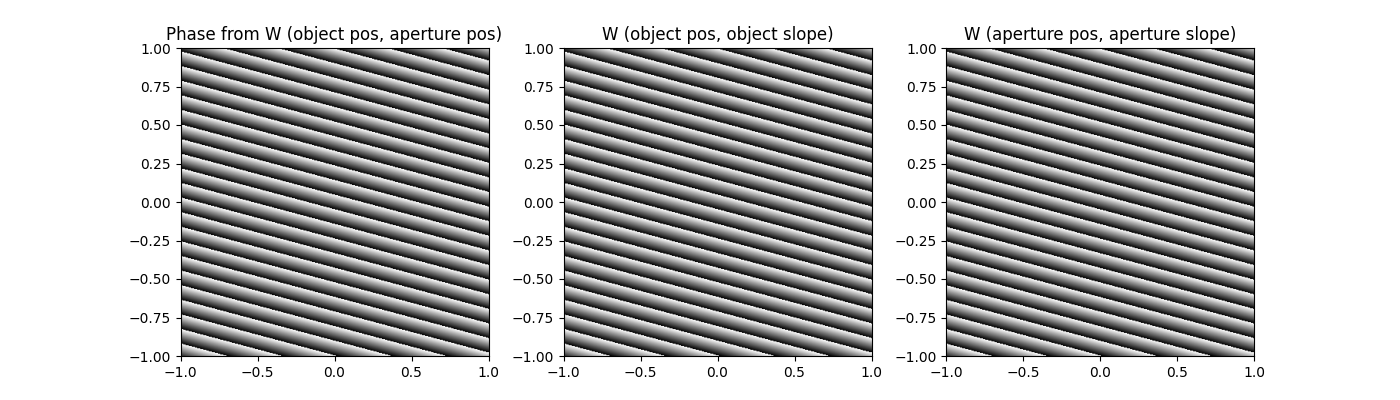

In [8]:
extent = 1
xa = np.linspace(-extent, extent, 400)
ya = np.linspace(-extent, extent, 400)
Xa, Ya = np.meshgrid(xa, ya)
xo, yo = 0.8, -3  # on-axis object point
z1 = 0.5
x_slope = (Xa - xo) / z1
y_slope = (Ya - yo) / z1

A = 0
B = 0
C = 0
D = 0
E = 4
F = 0
c = 0
e = 0
f = 0

W_opos_apos = aber_object_pos_aperture_pos(xo, yo, Xa, Ya, coeffs=(A, B, C, D, E, F, e, f, c))
W_opos_oslope = aber_object_pos_object_slope(xo, yo, x_slope, y_slope, z1, coeffs=(A, B, C, D, E, F, e, f, c))
W_apos_aslope = aber_aperture_pos_aperture_slope(Xa, Ya, (Xa - xo)/z1, (Ya - yo)/z1, z1, coeffs=(A, B, C, D, E, F, e, f, c))

wavelength = 11
k = 2 * np.pi / wavelength
chi_oa = np.exp(1j * k * W_opos_apos)
chi_o_os = np.exp(1j * k * W_opos_oslope)
chi_a_as = np.exp(1j * k * W_apos_aslope)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
im0 = axs[0].imshow(np.angle(chi_oa), extent=(-extent, extent, -extent, extent), cmap='gray')
axs[0].set_title("Phase from W (object pos, aperture pos)")
im1 = axs[1].imshow(np.angle(chi_o_os), extent=(-extent, extent, -extent, extent), cmap='gray')
axs[1].set_title("W (object pos, object slope)")
im2 = axs[2].imshow(np.angle(chi_a_as), extent=(-extent, extent, -extent, extent), cmap='gray')
axs[2].set_title("W (aperture pos, aperture slope)")

## Demo 1: Single Distorted Lens (Isotropic Distortion Only)

We create a `DistortedLens` with $M = -1000$ and a large isotropic distortion coefficient (`IsoDist=1e13`), then propagate a square grid of Gaussian beams through it to visualise barrel/pincushion distortion.

## How Distortion Works: The Gradient Mechanism

### The Key Physics: Phase Gradient → Ray Deflection

A lens works by applying a **phase shift** $\phi(x_a, y_a)$ to the wavefront. The ray optics limit tells us that the **ray deflection** (change in slope) is proportional to the **gradient** of the phase:

$$\Delta \begin{pmatrix} x_a' \\ y_a' \end{pmatrix} = \nabla_{xy} \phi(x_a, y_a) = \begin{pmatrix} \partial\phi/\partial x_a \\ \partial\phi/\partial y_a \end{pmatrix}$$

For a `DistortedLens`, the phase shift (in units of optical path length) is:

$$\phi(x_a, y_a, x_a', y_a') = -\frac{\rho^2}{2f} \;-\; W(x_a, y_a, x_a', y_a'; z_1)$$

where $W$ is the Seidel aberration function parametrized by **aperture position and aperture slope**.

### Why Distortion Depends on Object Position

The crucial insight: although the lens is at the aperture plane, the slope $(x_a', y_a')$ of a ray **encodes its origin**. A ray from object point $(x_o, y_o)$ arrives at the lens with slope:

$$x_a' = \frac{x_a - x_o}{z_1}, \quad y_a' = \frac{y_a - y_o}{z_1}$$

so $x_o = x_a - z_1 x_a'$. The Seidel function $W$ depends on $x_a'$ through $R = (x_a - x_a' z_1)^2 + \dots = x_o^2 + y_o^2$, which means:

> **Different object points → different slopes at the lens → different values of $W$ → different phase gradients → different image shifts.**

### The Distortion Terms Specifically

Focus on the **isotropic distortion** term (coefficient $E$, called `IsoDist` in the code):

$$W_E = E \cdot R \cdot \chi = E \cdot (x_o^2 + y_o^2) \cdot (x_o x_a + y_o y_a)$$

Taking the gradient with respect to aperture slope $(x_a', y_a')$:

$$\frac{\partial W_E}{\partial x_a'} \propto E \cdot R \cdot x_a + \cdots$$

This gradient is **linear in the aperture coordinate** $x_a$ but its **magnitude depends on $R = x_o^2 + y_o^2$**, the object position. So:

- A point at the centre of the object ($x_o=0, y_o=0$): $R=0$, so **zero distortion**.
- A point far from the axis: $R$ is large, so **large distortion**.

This creates the characteristic **barrel** or **pincushion** pattern: the image shift is a function of distance from the optical axis.

For **anisotropic (spiral) distortion** (coefficient $c$, called `AnisoDist`):

$$W_c = c \cdot \chi \cdot \sigma = c \cdot (x_o x_a + y_o y_a) \cdot (x_o y_a - y_o x_a)$$

This cross-term creates a **rotation-like** shift that varies with object position, producing a spiral pattern.

### Summary: The "Linear Slope" Picture

```mermaid
flowchart LR
    A["Object point<br/>(x_o, y_o)"] --> B["Ray slope at lens<br/>x_a' = (x_a - x_o)/z_1"]
    B --> C["W(x_a, y_a, x_a', y_a')<br/>depends on slope"]
    C --> D["∇W gives<br/>slope kick Δx_a'"]
    D --> E["Image point shifts<br/>by Δx = z_2 · Δx_a'"]
    E --> F["Shift magnitude ∝ R<br/>= x_o² + y_o²"]
```

Below we demonstrate this with a single distorted lens.

In [4]:
gaussians_in = square_input_wave(waist=1e-8,
                                 voltage=100e3,
                                 aperture_length=4e-6)

input_detector = Detector(z=0.0, pixel_size = (1e-8, 1e-8), shape=(512, 512))
input_extent = input_detector.extent
grid_image = evaluate_gaussians_gpu_kernel_wrapper(gaussians_in, input_detector)

f = 1e-3
M = -1000
z1 = f * (1 - 1 / M)
z2 = f * (1 - M)
z1 = abs(z1)
z2 = abs(z2)
print(f"z1 = {z1:.4e} m, z2 = {z2:.4e} m")

distortion_lens = DistortedLens(focal_length=f, z=z1, object_plane_dist=z1, IsoDist=1e13, AnisoDist=0)
output_detector = Detector(z=z1+z2, pixel_size = (1e-8 * M, 1e-8 * M), shape=(512, 512))
output_extent = output_detector.extent

run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)),
    static_argnums=(1,),
)

gaussians_out = run_to_end_vmapped(
    gaussians_in, (distortion_lens, output_detector),
)

output_image = evaluate_gaussians_gpu_kernel_wrapper(gaussians_out, output_detector)

z1 = 1.0010e-03 m, z2 = 1.0010e+00 m


Text(0.5, 1.0, 'Input grid intensity (after lens)')

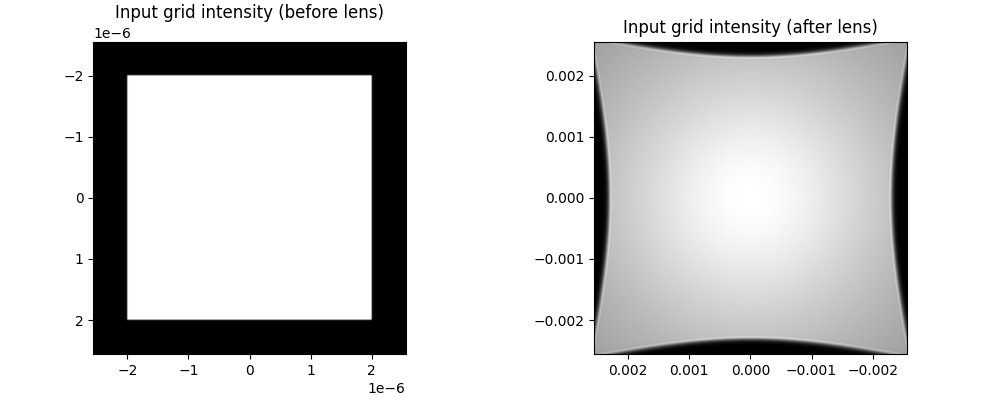

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axs[0].imshow(jnp.abs(grid_image), extent=input_extent, cmap='gray')
axs[0].set_title("Input grid intensity (before lens)")
axs[1].imshow(jnp.abs(output_image), extent=output_extent, cmap='gray')
axs[1].set_title("Input grid intensity (after lens)")

## Two-Lens System: Enabling Spiral Distortion

### Why Two Lenses?

For **isotropic distortion** ($E$ coefficient, barrel/pincushion), a single `DistortedLens` suffices because the distortion depends on $R \cdot \chi$, which is non-zero even for rays with zero slope at the lens plane.

For **anisotropic (spiral) distortion** ($c$ coefficient), the term is $c \cdot \chi \cdot \sigma$. The cross product $\sigma = x_o y_a - y_o x_a$ encodes the **skewness** between object and aperture vectors. For this to produce a visible spiral pattern, the ray at the lens aperture plane **must have a non-zero slope** — otherwise $x_o = x_a$ and $\sigma = 0$.

### The Setup

We use a **two-lens system**:

```mermaid
flowchart LR
    O["Object Plane<br/>z=0"] --> L1["Lens 1 (objective)<br/>f₁, M₁=-80"]
    L1 --> IP["Intermediate<br/>Image Plane"]
    IP --> L2["DistortedLens<br/>f₂, M₂=-50<br/>IsoDist, AnisoDist"]
    L2 --> D["Detector<br/>z=z₁+z₂+z₃+z₄"]
```

- **Lens 1** (ordinary `Lens`): Creates an intermediate image with magnification $M_1 = -80$. Rays arrive at the `DistortedLens` with **non-zero slopes** (they are converging to/form the intermediate image).
- **DistortedLens**: Sees rays with non-zero $(x_a', y_a')$, so $\sigma \neq 0$ and the spiral distortion term $c \cdot \chi \cdot \sigma$ is active.
- Total magnification: $M = M_1 \times M_2 = 4000\times$.

### What to Look For

The final plot overlays red dots at the Gaussian beam positions on the detector. With both `IsoDist` (barrel) and `AnisoDist` (spiral) active, you should see:
- **Barrel distortion**: Points further from the axis are displaced radially (inward for negative `IsoDist`, outward for positive).
- **Spiral distortion**: Points are twisted around the axis, with the twist angle depending on distance from the centre.

In [6]:
det_pixel_size = (1e-9, 1e-9)
det_shape = (512, 512)

gaussians_in = square_input_wave(waist=2e-9,
                                 voltage=100e3,
                                 aperture_length=4e-7,
                                 overlap_factor=0.25)

input_detector = Detector(z=0.0, pixel_size = det_pixel_size, shape=det_shape)
input_extent = input_detector.extent
grid_image = evaluate_gaussians_gpu_kernel_wrapper(gaussians_in, input_detector)

M1, M2 = -80, -50
f1, f2 = 1e-2, 1e-1

z1, z2 = calculate_z1_and_z2_from_M_and_f(M=M1, f=f1)
z3, z4 = calculate_z1_and_z2_from_M_and_f(M=M2, f=f2)
z1, z2, z3, z4 = map(abs, (z1, z2, z3, z4))
M = M1 * M2
print(f"M = {M:.4e}")

objective_lens = Lens(focal_length=f1, z=z1)
distortion_lens = DistortedLens(focal_length=f2, z=z1+z2+z3, object_plane_dist=z3, IsoDist=-5e8, AnisoDist=2e10)
output_detector = Detector(z=z1+z2+z3+z4, pixel_size = (det_pixel_size[0] * M, det_pixel_size[1] * M), shape=det_shape)
output_extent = output_detector.extent

run_to_end_vmapped = jax.jit(jax.vmap(run_to_end, in_axes=(0, None)), static_argnums=(1,))

gaussians_out = run_to_end_vmapped(
    gaussians_in, (objective_lens, distortion_lens, output_detector),
)

output_image = evaluate_gaussians_gpu_kernel_wrapper(gaussians_out, output_detector)

M = 4.0000e+03


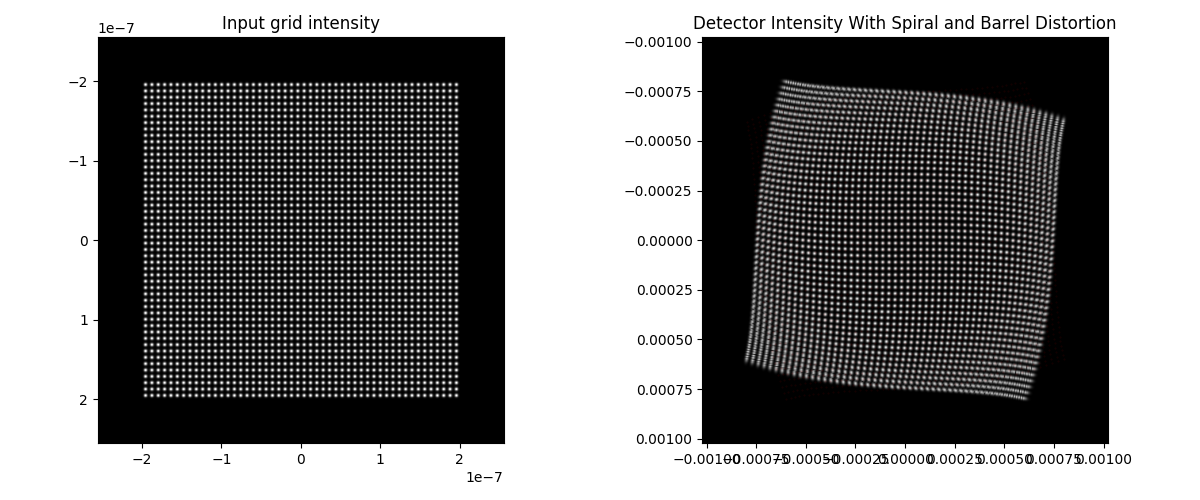

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(jnp.abs(grid_image), extent=input_extent, cmap='gray')
axs[0].set_title("Input grid intensity")

axs[1].imshow(jnp.abs(output_image), extent=output_extent, cmap='gray')
axs[1].plot(gaussians_out.x, gaussians_out.y, 'ro', markersize=0.4, alpha=0.1)

axs[1].set_title("Detector Intensity With Spiral and Barrel Distortion")

plt.tight_layout()